In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.matlib

In [3]:
from sklearn.metrics import accuracy_score
numpy.random.seed(42) 

In [4]:
#Training data and training label
#Creating dataset 
c1 = [2,3]# Cluster center for class 1 data
c2 = [10,11]# Cluster center for class 2 data
no = 50 # No of samples in a class
class1 = np.matlib.repmat(c1,no,1) + np.random.randn(no,len(c1))
class2 = np.matlib.repmat(c2, no,1)+ np.random.randn(no,len(c2))
D = np.append(class1,class2,axis =0)
Data = np.concatenate((D, np.ones((2*no,1))),axis = 1)
c1_label = np.ones((no,1))
c2_label = -1*np.ones((no,1))
label = np.concatenate((c1_label,c2_label),axis = 0)
Data = Data.T
y = label.T# True label

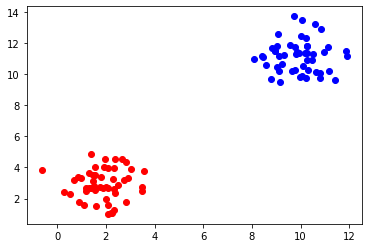

In [5]:
#Plotting data
import matplotlib.pyplot as plt
plt.plot(class1[:,0],class1[:,1],'ro',class2[:,0],class2[:,1],'bo')
plt.show()

In [6]:
#Validation data 
v1 = [5,4]# Cluster center for class1 data of validation data set
v2 = [7,12]# Cluster center for class 2 data of validation data set
v_no = 30# No of samples in a class
v_class1 = np.matlib.repmat(v1,v_no,1) + np.random.randn(v_no,len(v1))
v_class2 = np.matlib.repmat(v2, v_no,1)+ np.random.randn(v_no,len(v2))
v_D = np.append(v_class1,v_class2,axis =0)
v_Data = np.concatenate((v_D, np.ones((2*v_no,1))),axis = 1)
v_c1_label = np.ones((v_no,1))
v_c2_label = -1*np.ones((v_no,1))
v_label = np.concatenate((v_c1_label,v_c2_label),axis = 0)
v_Data = v_Data.T
v_y = v_label.T# Test labe

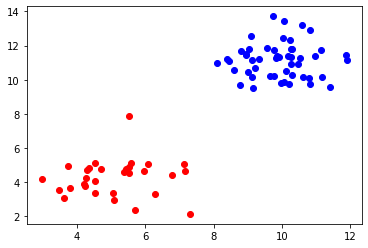

In [7]:
import matplotlib.pyplot as plt
plt.plot(v_class1[:,0],v_class1[:,1],'ro',class2[:,0],class2[:,1],'bo')
plt.show()

In [8]:
#The activation function used is sigmoid
def sigmoid(x):
     a = 1/(1+np.exp(-x))
     return a 
def prediction(w, Data):
     pred = []
     z = np.dot(w,Data)
     a = sigmoid(z)
     for i in range(0,len(a[0])):
         if (a[0][i] > 0.5): 
             pred.append(1)
         elif (a[0][i] <= 0.5):
             pred.append(-1)
     return pred

In [17]:
#Training part- In this step the loss is calculated and minimized with respect to weights.
learning_rate = 0.01
w = np.random.randn(1,3)
for i in range(1,1500):
     z = np.dot(w,Data)
     y_pred = prediction(w, Data)
     val = -np.multiply(y,z)
     J = np.sum(np.log(1+np.exp(val)))
     num = -np.multiply(y,np.exp(val))
     den = 1+np.exp(val)
     f = num/den
     gradJ = np.dot(Data,f.T)
     w = w - learning_rate*gradJ.T
     print("Epoch",i,"Loss",J,"Training Accuracy",accuracy_score(y[0],y_pred)*100) 
             

Epoch 1 Loss 474.48023801409 Training Accuracy 22.0
Epoch 2 Loss 1136.3684737682172 Training Accuracy 50.0
Epoch 3 Loss 810.1496366500669 Training Accuracy 50.0
Epoch 4 Loss 483.9847592662976 Training Accuracy 50.0
Epoch 5 Loss 162.24496174568085 Training Accuracy 50.0
Epoch 6 Loss 663.5722890324181 Training Accuracy 50.0
Epoch 7 Loss 1132.981312016021 Training Accuracy 50.0
Epoch 8 Loss 806.7623582161934 Training Accuracy 50.0
Epoch 9 Loss 480.5902948203258 Training Accuracy 50.0
Epoch 10 Loss 158.5676766485515 Training Accuracy 50.0
Epoch 11 Loss 294.39664255797646 Training Accuracy 50.0
Epoch 12 Loss 1130.9976370745424 Training Accuracy 50.0
Epoch 13 Loss 804.7794649413111 Training Accuracy 50.0
Epoch 14 Loss 478.6759704546688 Training Accuracy 50.0
Epoch 15 Loss 161.0177565535947 Training Accuracy 53.0
Epoch 16 Loss 11.752568240620905 Training Accuracy 100.0
Epoch 17 Loss 39.465891016571305 Training Accuracy 77.0
Epoch 18 Loss 33.1031161706185 Training Accuracy 83.0
Epoch 19 Loss 3

In [18]:
#Prediction for test data
Test_predict = prediction(w, v_Data)
print("Test Accuracy",accuracy_score(v_y[0], Test_predict)*100)

Test Accuracy 88.33333333333333


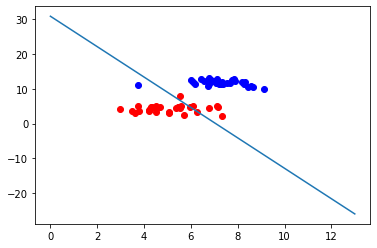

In [19]:
domain = np.linspace(0,13,100)
h_x = -(w[0,0]/w[0,1])*domain - (w[0,2]/w[0,1]) 
plt.plot(v_class1[:,0],v_class1[:,1],'ro',v_class2[:,0],v_class2[:,1],'bo')
plt.plot(domain,h_x)
plt.show()